In [6]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
from core import *

In [8]:
for k in tqdm([4,8]):
    pflist=[]
    rho=mpo(10,1e-6)
    for i in tqdm(range(20)):
        pf=trace(rho)
        pflist.append(pf)
        rho=product(rho,rho)
        rho=compress(rho,k)
    
    filename=f'{k}.svz.npz'
    np.savez(filename,pflist)
    

100%|██████████| 2/2 [00:00<00:00, 30.04it/s]


/opt/homebrew/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


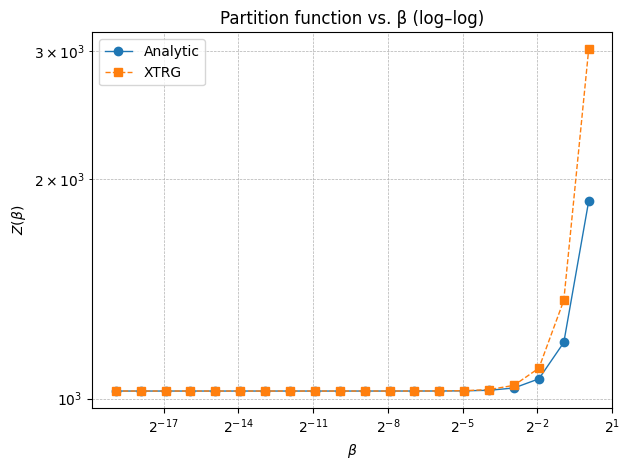

In [9]:
J = 1.0   
L = 10           

k_vals = np.arange(1, L + 1)                        # shape (L,)
eps_k = J * np.cos(k_vals * np.pi / (L + 1))        # shape (L,)
beta_vals = 2.0 ** np.arange(1, 21) * 1e-6          # shape (20,)

Z_vals = np.prod(1.0 + np.exp(-beta_vals[:, None] * eps_k), axis=1) 

xtrg_vals = np.asarray(pflist)          

fig, ax = plt.subplots()

ax.plot(beta_vals, Z_vals, marker='o',           linewidth=1, label='Analytic')
ax.plot(beta_vals, xtrg_vals, marker='s', ls='--', linewidth=1, label='XTRG')

ax.set_xscale('log', base=2)  
ax.set_yscale('log', base=10)                    

ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$Z(\beta)$')
ax.set_title('Partition function vs. β (log–log)')
ax.legend()
ax.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.savefig('xtrg.pdf')
plt.show()

In [204]:
b4=np.load('4.svz.npz')
b8=np.load('8.svz.npz')
b10=np.load('10.svz.npz')
b30=np.load('30.svz.npz')
b50=np.load('50.svz.npz')

x4=b4['arr_0']
x8=b8['arr_0']
x10=b10['arr_0']
x30=b30['arr_0']
x50=b50['arr_0']

diff4=np.abs(Z_vals-x4)
diff8=np.abs(Z_vals-x8)
diff10=np.abs(Z_vals-x10)
diff30=np.abs(Z_vals-x30)
diff50=np.abs(Z_vals-x50)




In [202]:
def free(partition_vals, beta_list):
   
    partition_vals = np.asarray(partition_vals, dtype=float)
    beta_list      = np.asarray(beta_list,      dtype=float)

    if partition_vals.shape != beta_list.shape:
        raise ValueError("partition_vals and beta_list must have the same shape")

    return -np.log2(partition_vals) / beta_list

In [205]:
f4=free(x4, beta_vals)
f8=free(x8, beta_vals)
f10=free(x10, beta_vals)
f30=free(x30, beta_vals)
f50=free(x50, beta_vals)

/var/folders/_h/79lspp25583bxfn_0hjyr5fc0000gn/T/ipykernel_94391/2706011622.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  partition_vals = np.asarray(partition_vals, dtype=float)


In [206]:
acc=free(Z_vals, beta_vals)
fdif4=np.abs(acc-f4)
fdif8=np.abs(acc-f8)
fdif10=np.abs(acc-f10)
fdif30=np.abs(acc-f30)
fdif50=np.abs(acc-f50)


In [207]:
relerror4=[np.abs(m/n) for m,n in zip(fdif4,acc)]
relerror8=[np.abs(m/n) for m,n in zip(fdif8,acc)]
relerror10=[np.abs(m/n) for m,n in zip(fdif10,acc)]
relerror30=[np.abs(m/n) for m,n in zip(fdif30,acc)]
relerror50=[np.abs(m/n) for m,n in zip(fdif50,acc)]


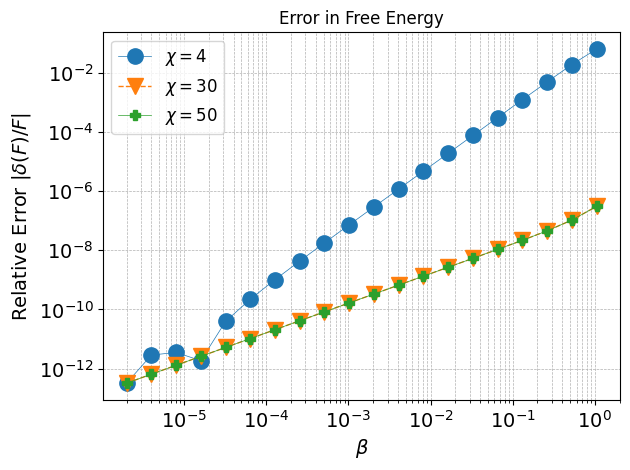

In [224]:
x = 2.0 ** np.arange(1, 21) * 1e-6

plt.figure()

plt.plot(x, relerror4, marker='o', linestyle='-', label='$\chi=4$',markersize=11, linewidth=0.5)
plt.plot(x, relerror30, marker='v', linestyle='--', label='$\chi=30$',markersize=12, linewidth=1)
plt.plot(x, relerror50, marker='P', linestyle='-', label='$\chi=50$', markersize=7, linewidth=0.5)

plt.yscale('log')
plt.xscale('log')

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12)  


plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'Relative Error $|\delta(F)/F|$', fontsize=14)
plt.title('Error in Free Energy')
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('error.pdf')

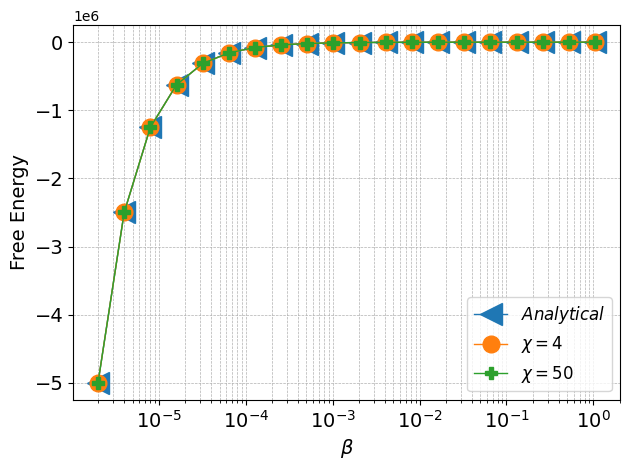

In [225]:
x = 2.0 ** np.arange(1, 21) * 1e-6

plt.figure()
plt.plot(x, acc, marker='<', linestyle='-', label='$Analytical$', markersize=16, linewidth=1)
plt.plot(x, f4, marker='o', linestyle='-', label='$\chi=4$', markersize=12, linewidth=1)
plt.plot(x, f50, marker='P', linestyle='-', label='$\chi=50$', markersize=8, linewidth=1)

plt.xscale('log')

plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'Free Energy', fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12)  

plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('f.pdf')

In [189]:
acc

array([-5.00000000e+06, -2.50000000e+06, -1.25000000e+06, -6.25000000e+05,
       -3.12500000e+05, -1.56250000e+05, -7.81250001e+04, -3.90625002e+04,
       -1.95312504e+04, -9.76562583e+03, -4.88281416e+03, -2.44140957e+03,
       -1.22070977e+03, -6.10364858e+02, -3.05202372e+02, -1.52641068e+02,
       -7.64002595e+01, -3.83592852e+01, -1.94956179e+01, -1.03620561e+01])

In [211]:
2**(20)*10**(-6)

1.048576